# Xenium Pancreas 377: Cell Clustering and Cluster Markers

This notebook derives cell clusters for the Xenium pancreas membrane
dataset and identifies cluster marker genes by sparse cell-level
detection AUC.

The dataset is an FFPE adult human pancreatic cancer sample, Stage III
adenocarcinoma, assayed with the Xenium Human Multi-Tissue and Cancer
377-gene panel:
<https://www.10xgenomics.com/datasets/ffpe-human-pancreas-with-xenium-multimodal-cell-segmentation-1-standard>.

The marker AUC matches the definition used by
`sccore::appendSpecificityMetricsToDE(..., append.auc = TRUE)`: AUC is
computed from binary gene detection, not expression magnitude. For
binary detection, the same AUC can be computed without per-gene `pROC`
calls as:

`0.5 + 0.5 * (fraction_detected_in_cluster - fraction_detected_outside_cluster)`.

That keeps the calculation sparse and avoids materializing a dense
cell-by-gene matrix.

## Configuration

In [ ]:
bundle_dir <- Sys.getenv(
  "CELLADMIX_PANCREAS_BUNDLE_DIR",
  unset = "/home/pkharchenko/baysor/rewrite/Baysor/examples/Xenium_pancreas_membrane_377/data"
)
output_dir <- Sys.getenv(
  "CELLADMIX_PANCREAS_OUTPUT_DIR",
  unset = "/home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10"
)
cluster_id <- Sys.getenv("CELLADMIX_PANCREAS_CLUSTER_ID", unset = "full")
num_threads <- as.integer(Sys.getenv("CELLADMIX_NUM_THREADS", unset = "10"))
min_molecules <- as.integer(Sys.getenv("CELLADMIX_MIN_MOLECULES", unset = "10"))
min_genes <- as.integer(Sys.getenv("CELLADMIX_MIN_GENES", unset = "5"))
graph_k <- as.integer(Sys.getenv("CELLADMIX_GRAPH_K", unset = "15"))
resolution <- as.numeric(Sys.getenv("CELLADMIX_CLUSTER_RESOLUTION", unset = "1"))
top_n <- as.integer(Sys.getenv("CELLADMIX_TOP_MARKERS", unset = "5"))
domain_id <- Sys.getenv("CELLADMIX_DOMAIN_ID", unset = "merged_annotation_domains")
domain_scales <- as.integer(strsplit(Sys.getenv("CELLADMIX_DOMAIN_SCALES", unset = "15,50,150"), ",")[[1]])
domain_n <- as.integer(Sys.getenv("CELLADMIX_N_DOMAINS", unset = "8"))
domain_transform <- Sys.getenv("CELLADMIX_DOMAIN_TRANSFORM", unset = "clr")
domain_smooth_k <- as.integer(Sys.getenv("CELLADMIX_DOMAIN_SMOOTH_K", unset = "20"))
domain_smooth_lambda <- as.numeric(Sys.getenv("CELLADMIX_DOMAIN_SMOOTH_LAMBDA", unset = "0.5"))
domain_min_region_size <- as.integer(Sys.getenv("CELLADMIX_DOMAIN_MIN_REGION_SIZE", unset = "25"))
force_domains <- tolower(Sys.getenv("CELLADMIX_FORCE_DOMAINS", unset = "false")) %in% c("1", "true", "yes")

list(
  bundle_dir = bundle_dir,
  output_dir = output_dir,
  cluster_id = cluster_id,
  num_threads = num_threads,
  min_molecules = min_molecules,
  min_genes = min_genes,
  graph_k = graph_k,
  resolution = resolution,
  top_n = top_n,
  domain_id = domain_id,
  domain_scales = domain_scales,
  domain_n = domain_n,
  domain_transform = domain_transform,
  domain_smooth_k = domain_smooth_k,
  domain_smooth_lambda = domain_smooth_lambda,
  domain_min_region_size = domain_min_region_size,
  force_domains = force_domains
)

$bundle_dir
[1] "/home/pkharchenko/baysor/rewrite/Baysor/examples/Xenium_pancreas_membrane_377/data"

$output_dir
[1] "/home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10"

$cluster_id
[1] "full"

$num_threads
[1] 10

$min_molecules
[1] 10

$min_genes
[1] 5

$graph_k
[1] 15

$resolution
[1] 1

$top_n
[1] 5

$domain_id
[1] "merged_annotation_domains"

$domain_scales
[1]  15  50 150

$domain_n
[1] 8

$domain_transform
[1] "clr"

$domain_smooth_k
[1] 20

$domain_smooth_lambda
[1] 0.5

$domain_min_region_size
[1] 25

$force_domains
[1] FALSE

## Prepare Input

In [ ]:
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
prep_rds <- file.path(output_dir, "prep.rds")

if (file.exists(prep_rds)) {
  prep <- readRDS(prep_rds)
  ds <- cellAdmix(prep)
} else {
  ds <- cellAdmix(bundle_dir, output_dir = output_dir, prefer_parquet = TRUE)
  prep <- ds$prep
  saveRDS(prep, prep_rds)
}

ds

cellAdmix dataset
  format: xenium 
  output cache: configured
  threads: 10 
  molecules: transcripts.parquet 
  cells: cells.parquet 
  annotation: none
  note: provide annotation=, call $set_annotation(), or run $cluster()

List of 7
 $ project_dir: chr "/home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10"
 $ source     :List of 3
 $ crops      : NULL
 $ defaults   :List of 4
 $ paths      :List of 3
 $ probe      :List of 7
 $ warnings   : chr "The cell metadata file does not expose a cell_type column; clustering will likely be needed before fitting."
 - attr(*, "class")= chr "celladmix_prep"

[1] "The cell metadata file does not expose a cell_type column; clustering will likely be needed before fitting."

## Cluster Cells

In [ ]:
cluster_rds <- file.path(output_dir, "annotations", cluster_id, "cluster_result.rds")

if (file.exists(cluster_rds)) {
  clust <- readRDS(cluster_rds)
} else {
  clust <- ds$cluster(name = cluster_id, active = TRUE,
    min_molecules = min_molecules, min_genes = min_genes,
    graph_k = graph_k, resolution = resolution, compute_umap = TRUE, num_threads = num_threads,
    store_mode = "counts", umap_parallel_optimization = TRUE, verbose = TRUE)
  saveRDS(clust, cluster_rds)
}
ds$set_annotation(stats::setNames(paste0("cluster_", clust$clusters$cluster), clust$clusters$cell_id),
  name = cluster_id, active = TRUE)

str(clust$summary, max.level = 1)

List of 11
 $ n_cells                   : num 125723
 $ n_clusters                : num 20
 $ n_variable_genes          : num 541
 $ variable_genes            : chr [1:541] "LAMP3" "HES4" "FBLN1" "SOX2" ...
 $ pca_variance_explained    : num [1:30] 0.0983 0.0611 0.0287 0.0222 0.018 ...
 $ min_cell_size             : int 10
 $ cells_max                 : int NA
 $ compute_umap              : logi TRUE
 $ num_threads               : int 10
 $ umap_parallel_optimization: logi TRUE
 $ resolution                : num 1


    1     2     3     4     5     6     7     8     9    10    11    12    13 
10905  7322 21044  8346  7026  2553 14950  8605  2447  2212  4746  3731  4325 
   14    15    16    17    18    19    20 
 4333  3139  7326  6483  2475  2098  1657 

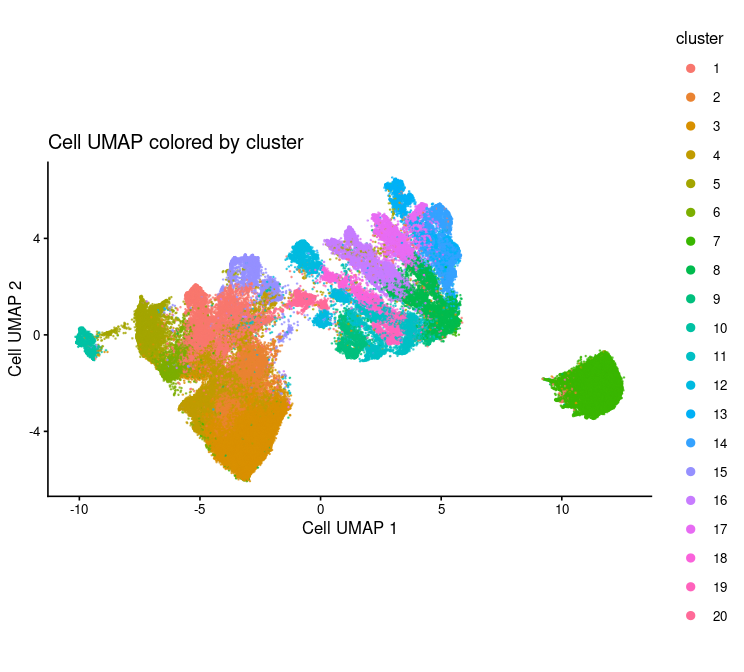

In [ ]:
umap_df <- clust$embedding
umap_df$cluster <- factor(umap_df$cluster)

ggplot(umap_df, aes(umap_1, umap_2, color = cluster)) +
  geom_point(size = 0.15, alpha = 0.6) +
  coord_equal() +
  guides(color = guide_legend(override.aes = list(size = 2, alpha = 1))) +
  labs(title = "Cell UMAP colored by cluster", x = "Cell UMAP 1", y = "Cell UMAP 2") +
  theme_classic(base_size = 10)

## Sparse Marker AUC

In [ ]:
score_cluster_markers_auc <- function(counts, clusters, normalization_scale = 10000,
                                      min_expression_fraction = 0.05, min_logfc = 0) {
  stopifnot(inherits(counts, "dgCMatrix"))
  common_cells <- intersect(colnames(counts), names(clusters))
  counts <- counts[, common_cells, drop = FALSE]
  clusters <- factor(clusters[common_cells])

  lib_size <- Matrix::colSums(counts)
  scale <- normalization_scale / pmax(lib_size, 1)
  norm <- counts
  norm@x <- norm@x * rep.int(scale, diff(norm@p))

  detected <- counts
  detected@x <- rep(1, length(detected@x))

  total_detected <- Matrix::rowSums(detected)
  total_expression <- Matrix::rowSums(norm)
  n_cells <- ncol(counts)

  out <- lapply(levels(clusters), function(cluster) {
    in_cluster <- clusters == cluster
    n_in <- sum(in_cluster)
    n_out <- n_cells - n_in
    detected_in <- Matrix::rowSums(detected[, in_cluster, drop = FALSE])
    expression_in <- Matrix::rowSums(norm[, in_cluster, drop = FALSE])

    fraction_in <- detected_in / n_in
    fraction_out <- (total_detected - detected_in) / pmax(n_out, 1)
    auc <- 0.5 + 0.5 * (fraction_in - fraction_out)

    mean_in <- expression_in / n_in
    mean_out <- (total_expression - expression_in) / pmax(n_out, 1)
    logfc <- log2((mean_in + 1e-6) / (mean_out + 1e-6))
    precision <- detected_in / pmax(total_detected, 1)
    specificity <- (n_cells - total_detected) / pmax(n_cells - detected_in, 1)

    data.frame(cluster = cluster, gene = rownames(counts), auc = as.numeric(auc),
      logfc = as.numeric(logfc), expression_fraction = as.numeric(fraction_in),
      outside_expression_fraction = as.numeric(fraction_out),
      precision = as.numeric(precision), specificity = as.numeric(specificity),
      mean_norm_in = as.numeric(mean_in), mean_norm_out = as.numeric(mean_out),
      stringsAsFactors = FALSE)
  })

  markers <- do.call(rbind, out)
  markers <- markers[markers$expression_fraction >= min_expression_fraction &
                       markers$logfc > min_logfc, , drop = FALSE]
  markers <- markers[order(markers$cluster, -markers$auc, -markers$logfc), , drop = FALSE]
  rownames(markers) <- NULL
  markers
}

top_markers_by_cluster <- function(markers, n = 5) {
  cluster_levels <- unique(as.character(markers$cluster))
  if (all(!is.na(suppressWarnings(as.integer(cluster_levels))))) {
    cluster_levels <- as.character(sort(as.integer(cluster_levels)))
  }
  pieces <- split(markers, factor(markers$cluster, levels = cluster_levels))
  out <- do.call(rbind, lapply(pieces, head, n))
  rownames(out) <- NULL
  out
}

In [ ]:
t_start <- Sys.time()
counts <- ds$counts(force = FALSE, num_threads = num_threads, verbose = TRUE)

[INFO 18:37:48 +0.002s] Opening Xenium transcripts parquet for counts-only store: /home/pkharchenko/baysor/rewrite/Baysor/examples/Xenium_pancreas_membrane_377/data/transcripts.parquet (0.000s)
[INFO 18:37:48 +0.002s] Selected 9 transcript row groups for counts-only store (0.001s)
[INFO 18:37:48 +0.086s] Scanned counts-only transcript batches: 1, rows=65536, kept=41947 (0.084s)
[INFO 18:37:48 +0.558s] Scanned counts-only transcript batches: 16, rows=1048576, kept=753717 (0.472s)
[INFO 18:37:49 +1.023s] Scanned counts-only transcript batches: 31, rows=2031616, kept=1446189 (0.465s)
[INFO 18:37:49 +1.469s] Scanned counts-only transcript batches: 46, rows=3014656, kept=2131736 (0.446s)
[INFO 18:37:50 +1.981s] Scanned counts-only transcript batches: 62, rows=4063232, kept=2925575 (0.512s)
[INFO 18:37:50 +2.440s] Scanned counts-only transcript batches: 77, rows=5046272, kept=3699161 (0.459s)
[INFO 18:37:50 +2.892s] Scanned counts-only transcript batches: 92, rows=6029312, kept=4489524 (0.45

Marker scoring elapsed: 6.375 seconds

Count matrix: 377 x 125723 with 2778919 non-zero entries

'data.frame':   906 obs. of  10 variables:
 $ cluster                    : chr  "1" "1" "1" "1" ...
 $ gene                       : chr  "PTPRC" "CXCR4" "MS4A6A" "IL7R" ...
 $ auc                        : num  0.66 0.644 0.595 0.593 0.584 ...
 $ logfc                      : num  2.64 2.53 2.12 2.69 1.95 ...
 $ expression_fraction        : num  0.439 0.419 0.311 0.257 0.305 ...
 $ outside_expression_fraction: num  0.119 0.132 0.121 0.07 0.137 ...
 $ precision                  : num  0.26 0.232 0.197 0.258 0.174 ...
 $ specificity                : num  0.887 0.875 0.887 0.935 0.871 ...
 $ mean_norm_in               : num  310 306 204 241 188 ...
 $ mean_norm_out              : num  49.9 52.9 46.9 37.3 48.9 ...

## Top Markers

In [ ]:
top_markers

    cluster    gene       auc     logfc expression_fraction
1         1   PTPRC 0.6600005 2.6351970           0.4386061
2         1   CXCR4 0.6435063 2.5306722           0.4190738
3         1  MS4A6A 0.5951993 2.1171705           0.3112334
4         1    IL7R 0.5933040 2.6923158           0.2565796
5         1    AIF1 0.5838465 1.9452256           0.3048143
6         2   SFRP2 0.8861681 2.7117580           0.9842939
7         2   PTPRC 0.6218421 1.9086591           0.3758536
8         2   CXCR4 0.6091111 1.7915914           0.3624693
9         2    IL7R 0.6073989 2.4675050           0.2884458
10        2   SFRP4 0.5862407 1.7046981           0.3242284
11        3    VCAN 0.8114031 2.7336034           0.8674206
12        3    FBN1 0.8106519 3.0926821           0.7662517
13        3  COL5A2 0.7785700 3.1092078           0.6712602
14        3   SFRP2 0.7725782 2.6570790           0.7108439
15        3   THBS2 0.7565078 3.2912651           0.5934233
16        4   PMP22 0.6834058 2.6108992 

## Top Marker Expression on Cell UMAP

Each panel shows the top detection-AUC marker for one cluster.
Expression is library-size normalized, log-transformed, and plotted on
the cell UMAP.

In [ ]:
normalized_gene_expression <- function(counts, gene, normalization_scale = 10000) {
  if (!gene %in% rownames(counts)) {
    stop("Gene not found in count matrix: ", gene)
  }
  lib_size <- Matrix::colSums(counts)
  expr <- as.numeric(counts[gene, , drop = TRUE])
  log1p(expr * normalization_scale / pmax(lib_size, 1))
}

plot_expression_umap_panel <- function(umap, counts, top_markers, point_cex = 0.045) {
  common_cells <- intersect(colnames(counts), umap$cell_id)
  counts <- counts[, common_cells, drop = FALSE]
  umap <- umap[match(common_cells, umap$cell_id), , drop = FALSE]

  top_gene <- top_markers[!duplicated(top_markers$cluster), c("cluster", "gene", "auc")]
  top_gene$cluster <- as.character(top_gene$cluster)
  top_gene <- top_gene[order(as.integer(top_gene$cluster)), , drop = FALSE]

  old_par <- par(no.readonly = TRUE)
  on.exit(par(old_par), add = TRUE)
  par(mfrow = c(4, 5), mar = c(0.2, 0.2, 1.7, 0.2), oma = c(0.2, 0.2, 1.0, 0.2))

  pal <- colorRampPalette(c("#e6e6e6", "#b9d9ea", "#3c8dbc", "#08306b", "#67000d"))(101)
  for (i in seq_len(nrow(top_gene))) {
    gene <- top_gene$gene[[i]]
    expr <- normalized_gene_expression(counts, gene)
    q <- stats::quantile(expr[expr > 0], probs = 0.995, na.rm = TRUE, names = FALSE)
    q <- if (is.finite(q) && q > 0) q else max(expr, na.rm = TRUE)
    scaled <- pmin(expr / q, 1)
    colors <- pal[pmax(1, round(scaled * 100) + 1)]
    colors[expr <= 0] <- "#d9d9d9"
    ord <- order(expr)
    plot(umap$umap_1[ord], umap$umap_2[ord], pch = 16, cex = point_cex, col = colors[ord],
      asp = 1, axes = FALSE, xlab = "", ylab = "",
      main = paste0("C", top_gene$cluster[[i]], ": ", gene))
    box(col = "grey80")
  }
  mtext("Top marker expression by cluster", outer = TRUE, cex = 0.9)
}

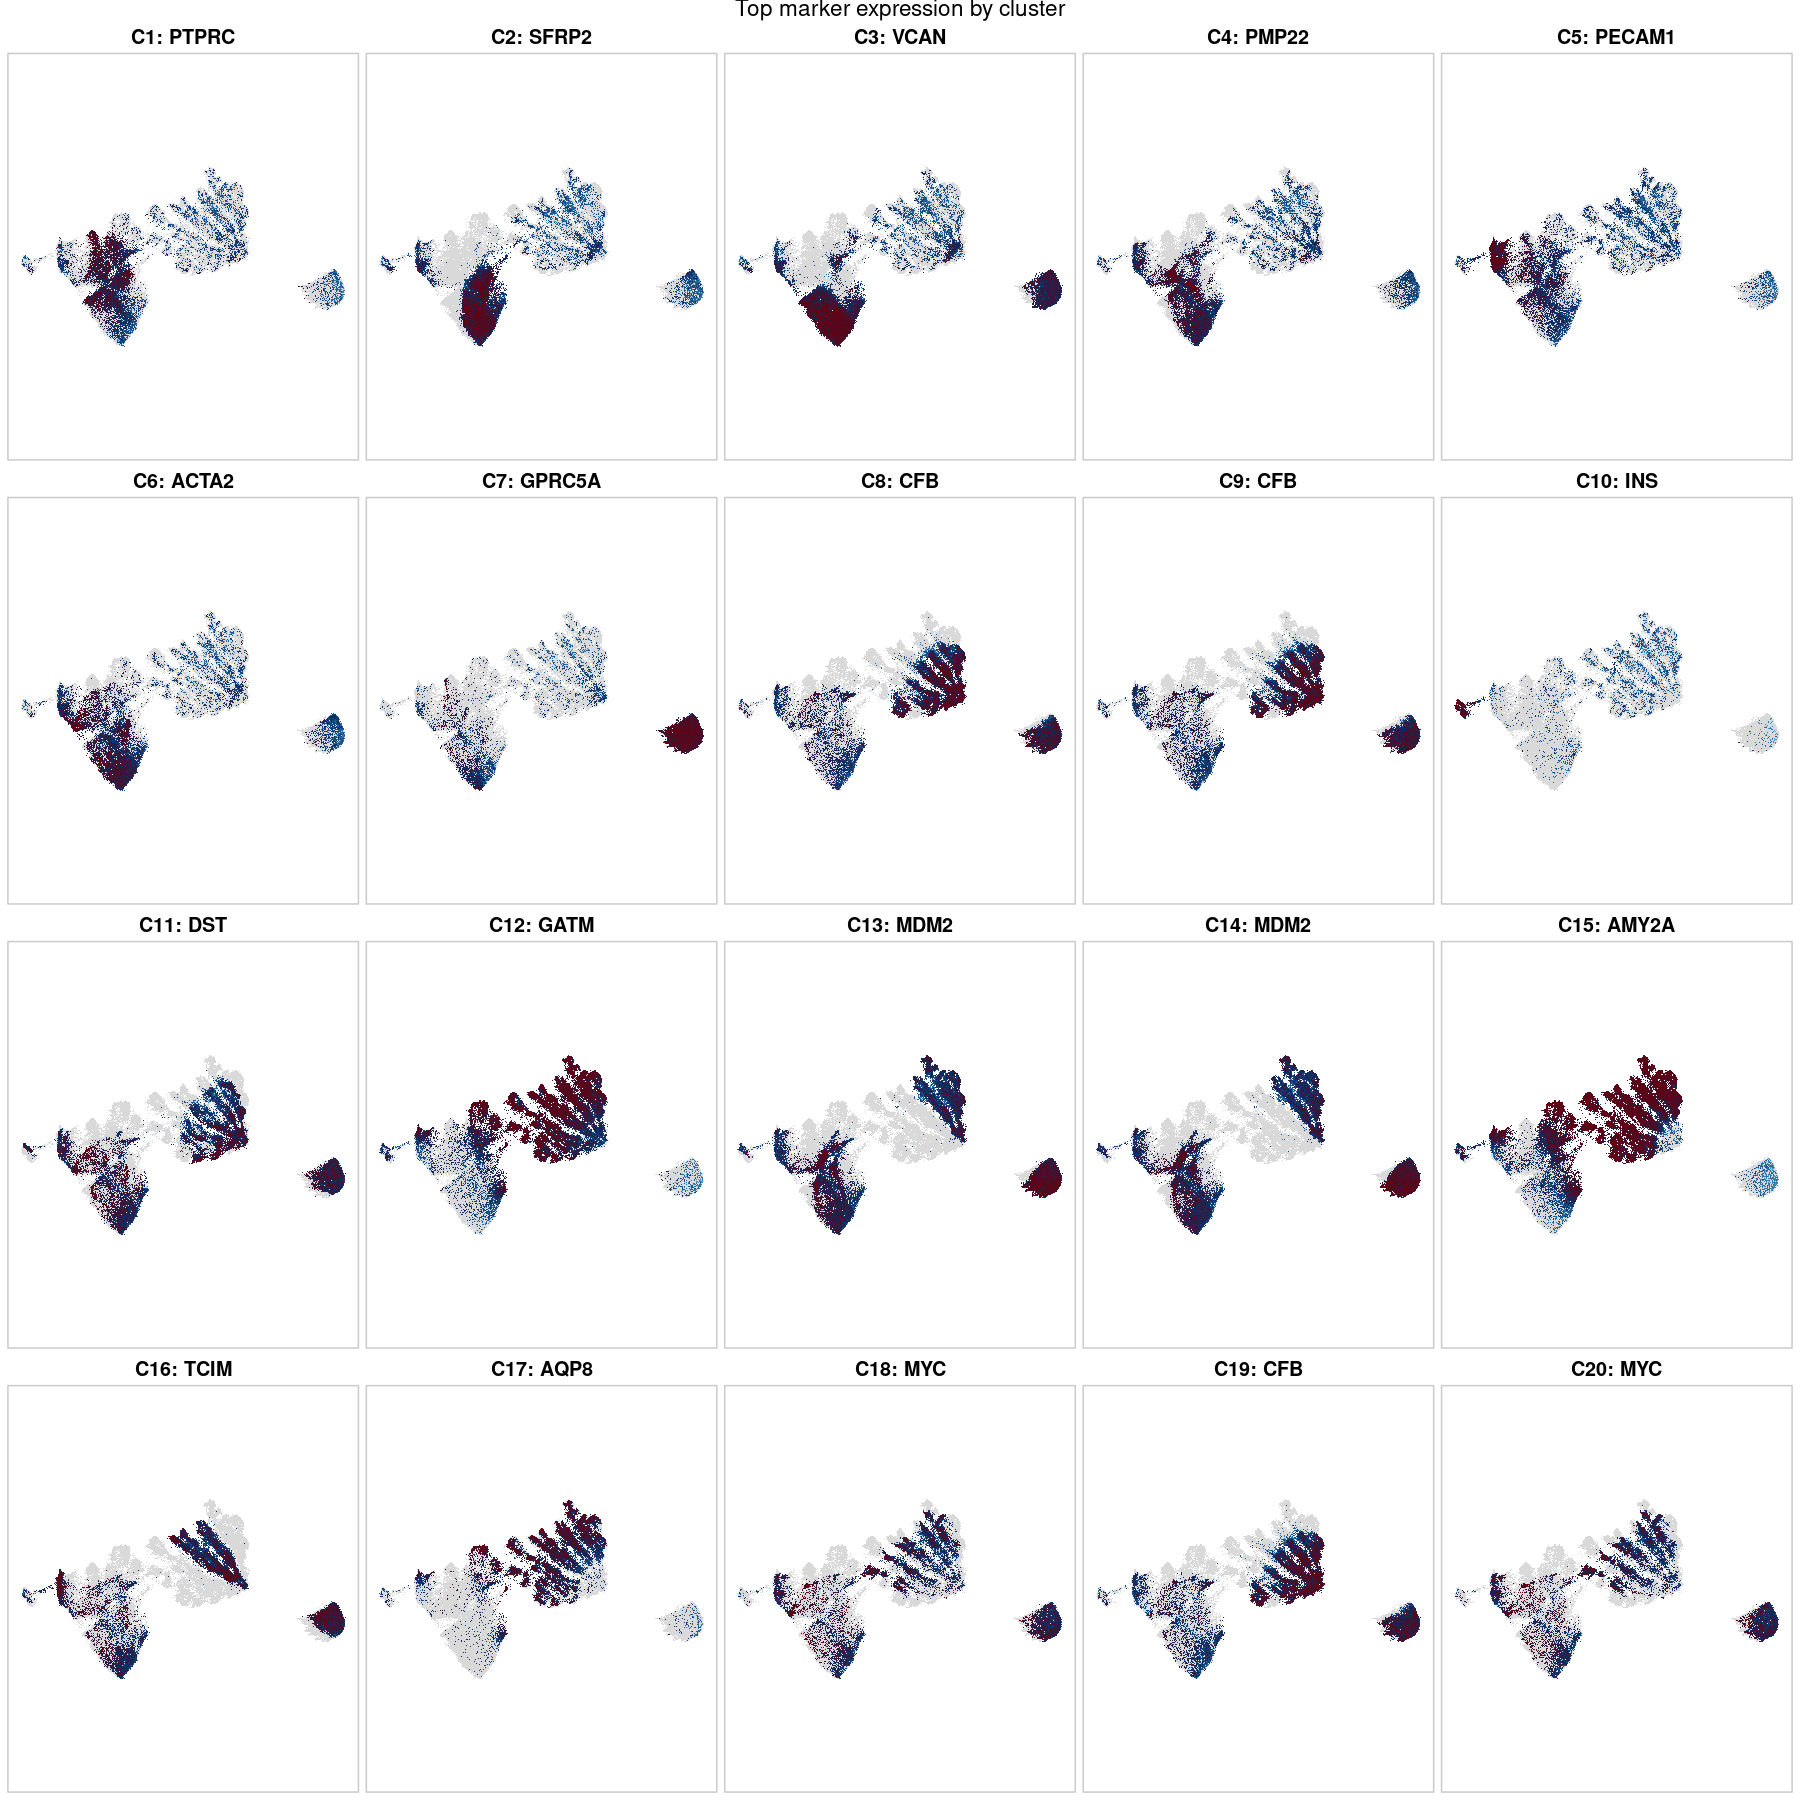

In [ ]:
plot_expression_umap_panel(umap_df, counts, top_markers)

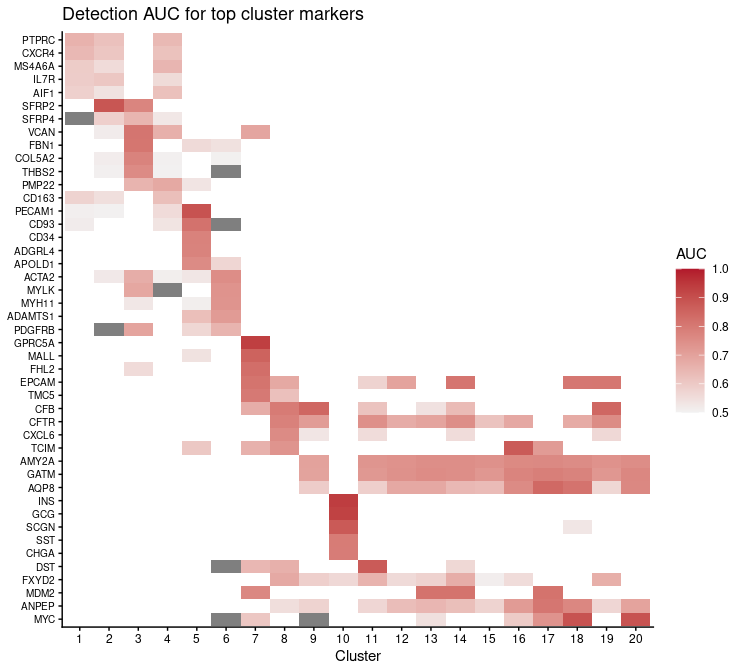

In [ ]:
plot_markers <- unique(top_markers$gene)
heat_df <- markers[markers$gene %in% plot_markers, , drop = FALSE]
heat_df$cluster <- factor(heat_df$cluster, levels = levels(cluster_labels))
heat_df$gene <- factor(heat_df$gene, levels = rev(plot_markers))

ggplot(heat_df, aes(cluster, gene, fill = auc)) +
  geom_tile() +
  scale_fill_gradient(low = "grey95", high = "#B2182B", limits = c(0.5, 1)) +
  labs(title = "Detection AUC for top cluster markers", x = "Cluster", y = NULL, fill = "AUC") +
  theme_classic(base_size = 9) +
  theme(axis.text.y = element_text(size = 6))

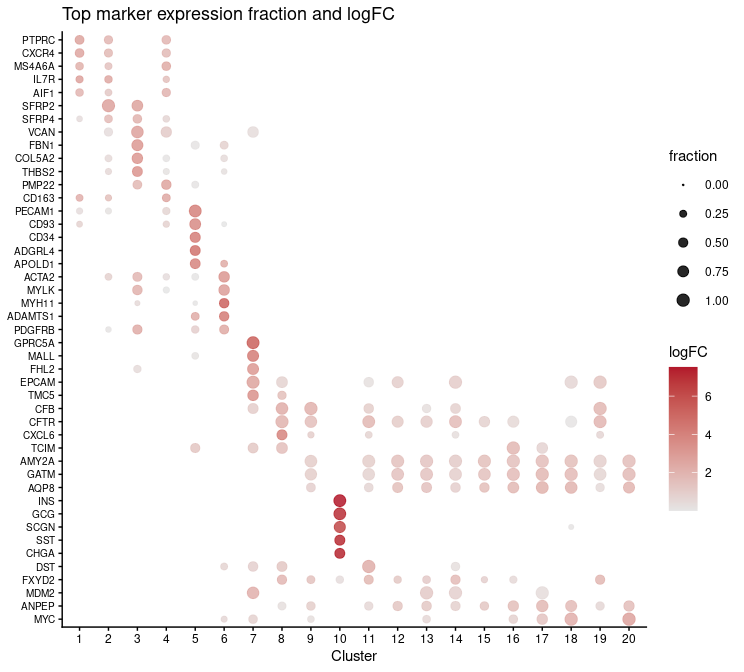

In [ ]:
dot_df <- markers[markers$gene %in% plot_markers, , drop = FALSE]
dot_df$cluster <- factor(dot_df$cluster, levels = levels(cluster_labels))
dot_df$gene <- factor(dot_df$gene, levels = rev(plot_markers))

ggplot(dot_df, aes(cluster, gene)) +
  geom_point(aes(size = expression_fraction, color = logfc), alpha = 0.85) +
  scale_color_gradient2(low = "#2166AC", mid = "grey90", high = "#B2182B", midpoint = 0) +
  scale_size(range = c(0.2, 3.2), limits = c(0, 1)) +
  labs(title = "Top marker expression fraction and logFC", x = "Cluster", y = NULL,
       color = "logFC", size = "fraction") +
  theme_classic(base_size = 9) +
  theme(axis.text.y = element_text(size = 6))

## Proposed Cluster Annotation

These labels are marker-based provisional annotations. The broader
merged labels are intended for downstream membrane-scoring diagnostics;
the cluster-specific labels preserve the marker distinctions used to
assign them.

In [ ]:
cluster_annotation <- data.frame(
  cluster = as.character(1:20),
  cluster_label = c(
    "Immune, lymphoid/myeloid mixed",
    "SFRP2+ cancer-associated fibroblast",
    "Matrix fibroblast / CAF",
    "Macrophage / myeloid",
    "Endothelial",
    "Mural smooth muscle / pericyte",
    "Ductal/tumor epithelial, GPRC5A+",
    "Inflammatory ductal epithelial",
    "CFB+ exocrine epithelial",
    "Endocrine islet",
    "CFTR+/AMY2A+ exocrine epithelial",
    "Acinar/ductal exocrine epithelial",
    "MDM2+ exocrine epithelial",
    "MDM2+/EPCAM+ ductal epithelial",
    "Acinar epithelial",
    "TCIM+ acinar/ductal epithelial",
    "AQP8+/ANPEP+ acinar epithelial",
    "MYC+ epithelial",
    "CFB+ ductal/exocrine epithelial",
    "MYC+ acinar epithelial"
  ),
  merged_annotation = c(
    "Immune",
    "Fibroblast / CAF",
    "Fibroblast / CAF",
    "Immune",
    "Endothelial",
    "Mural / pericyte",
    "Ductal/tumor epithelial",
    "Ductal/tumor epithelial",
    "Exocrine epithelial",
    "Endocrine",
    "Exocrine epithelial",
    "Exocrine epithelial",
    "Exocrine epithelial",
    "Ductal/tumor epithelial",
    "Exocrine epithelial",
    "Exocrine epithelial",
    "Exocrine epithelial",
    "Exocrine epithelial",
    "Ductal/tumor epithelial",
    "Exocrine epithelial"
  ),
  marker_rationale = c(
    "PTPRC, CXCR4, IL7R, TRAC, CD3E/CD8A, AIF1",
    "SFRP2/SFRP4 with immune-adjacent signal",
    "VCAN, FBN1, COL5A2, SFRP2, THBS2, PDGFRB",
    "MS4A6A, CD163, AIF1, FCGR3A, MRC1, VSIG4",
    "PECAM1, CD93, CD34, ADGRL4, APOLD1, VWF",
    "ACTA2, MYLK, MYH11, ADAMTS1, PDGFRB, CNN1",
    "GPRC5A, MALL, FHL2, EPCAM, GPX2, MET, SERPINB3",
    "CFTR, CFB, CXCL6, EPCAM, FXYD2, PROX1",
    "CFB, CFTR, AMY2A, GATM, AQP8",
    "INS, GCG, SCGN, SST, CHGA, PCSK2",
    "DST, CFTR, AMY2A, GATM, FXYD2, PROX1",
    "GATM, AMY2A, AQP8, CFTR, ANPEP",
    "MDM2, GATM, AMY2A, CFTR, AQP8",
    "MDM2, EPCAM, CFTR, GATM, AMY2A",
    "AMY2A, GATM, AQP8, ANPEP",
    "TCIM, GATM, AMY2A, AQP8, ANPEP",
    "AQP8, ANPEP, GATM, AMY2A, FKBP11",
    "MYC, AQP8, EPCAM, GATM, ANPEP, AMY2A",
    "CFB, EPCAM, CFTR, AMY2A, GATM, FXYD2",
    "MYC, GATM, AQP8, AMY2A, ANPEP"
  ),
  stringsAsFactors = FALSE
)

cluster_annotation

   cluster                       cluster_label       merged_annotation
1        1      Immune, lymphoid/myeloid mixed                  Immune
2        2 SFRP2+ cancer-associated fibroblast        Fibroblast / CAF
3        3             Matrix fibroblast / CAF        Fibroblast / CAF
4        4                Macrophage / myeloid                  Immune
5        5                         Endothelial             Endothelial
6        6      Mural smooth muscle / pericyte        Mural / pericyte
7        7    Ductal/tumor epithelial, GPRC5A+ Ductal/tumor epithelial
8        8      Inflammatory ductal epithelial Ductal/tumor epithelial
9        9            CFB+ exocrine epithelial     Exocrine epithelial
10      10                     Endocrine islet               Endocrine
11      11    CFTR+/AMY2A+ exocrine epithelial     Exocrine epithelial
12      12   Acinar/ductal exocrine epithelial     Exocrine epithelial
13      13           MDM2+ exocrine epithelial     Exocrine epithelial
14    

Wrote cluster annotation: /home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10/annotations/full/cluster_annotation.csv 

Wrote cell annotation: /home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10/annotations/full/annotation.csv 

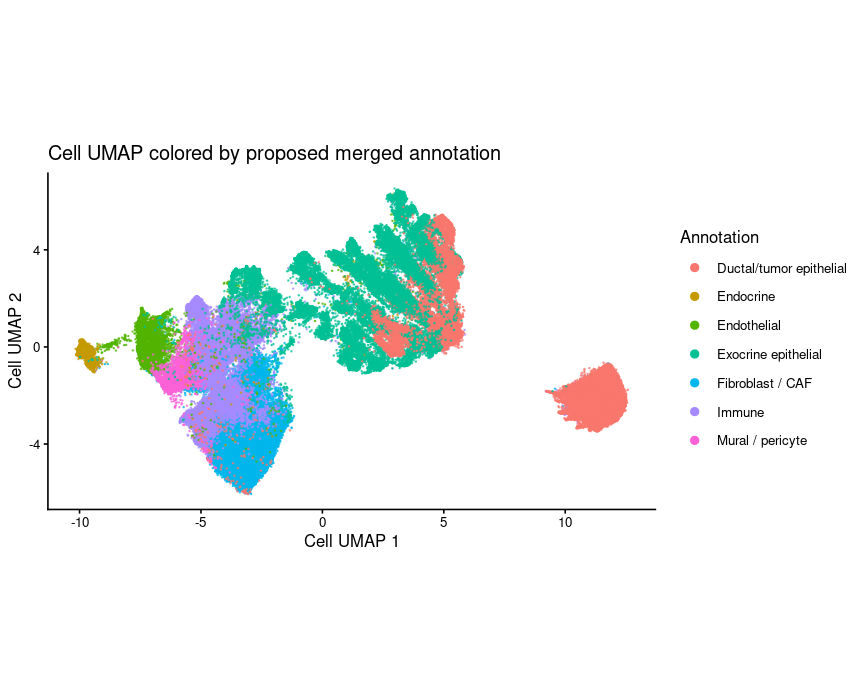

In [ ]:
umap_annot <- merge(umap_df, cluster_annotation[, c("cluster", "merged_annotation")],
  by = "cluster", all.x = TRUE, sort = FALSE)
umap_annot$merged_annotation <- factor(umap_annot$merged_annotation)

ggplot(umap_annot, aes(umap_1, umap_2, color = merged_annotation)) +
  geom_point(size = 0.15, alpha = 0.6) +
  coord_equal() +
  guides(color = guide_legend(override.aes = list(size = 2, alpha = 1))) +
  labs(title = "Cell UMAP colored by proposed merged annotation",
       x = "Cell UMAP 1", y = "Cell UMAP 2", color = "Annotation") +
  theme_classic(base_size = 10)

## Spatial Domain Detection

Domains are inferred from spatial neighborhoods of the merged cell
annotation, not from expression directly. The domain call uses
multiscale local composition, k-means initialization, Potts smoothing,
and connected-region extraction.

In [ ]:
domain_dir <- file.path(prep$paths$annotations_dir, domain_id)
domain_domains_path <- file.path(domain_dir, "cell_domains.csv")
if (!force_domains && file.exists(domain_domains_path)) {
  domains <- ds$load_domains(domain_id)
  domains$clust <- clust
  cat("Loaded existing domains:", domain_domains_path, "\n")
} else {
  domains <- ds$identify_domains(
    name = domain_id,
    annotation = "merged_annotation",
    clust = clust,
    scales = domain_scales,
    n_domains = domain_n,
    transform = domain_transform,
    include_self = TRUE,
    include_center_type = FALSE,
    smooth_k = domain_smooth_k,
    smooth_lambda = domain_smooth_lambda,
    min_region_size = domain_min_region_size,
    num_threads = num_threads,
    verbose = TRUE
  )
}

Loaded existing domains: /home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10/annotations/merged_annotation_domains/cell_domains.csv 

 list()

In [ ]:
domain_composition <- celladmix_domain_composition(domains)
domain_composition[order(domain_composition$domain, -domain_composition$fraction), ]

   domain              annotation     fraction n_cells
41     D1     Exocrine epithelial 0.6996027052   32973
33     D1 Ductal/tumor epithelial 0.1954022989   32973
17     D1             Endothelial 0.0487975010   32973
1      D1                  Immune 0.0464319292   32973
9      D1        Fibroblast / CAF 0.0078245838   32973
25     D1        Mural / pericyte 0.0016377036   32973
49     D1               Endocrine 0.0003032784   32973
42     D2     Exocrine epithelial 0.3396414740   25047
2      D2                  Immune 0.2114424881   25047
34     D2 Ductal/tumor epithelial 0.1902822693   25047
10     D2        Fibroblast / CAF 0.1863297002   25047
18     D2             Endothelial 0.0637601310   25047
26     D2        Mural / pericyte 0.0082245379   25047
50     D2               Endocrine 0.0003193995   25047
11     D3        Fibroblast / CAF 0.3753981867    8162
3      D3                  Immune 0.2658662093    8162
27     D3        Mural / pericyte 0.2167360941    8162
19     D3 

In [ ]:
domain_size <- as.integer(domains$diagnostics$domain_sizes)
domain_names <- names(domains$diagnostics$domain_sizes)
domain_diag <- data.frame(domain = domain_names, n_cells = domain_size, stringsAsFactors = FALSE)
domain_diag$fraction <- domain_diag$n_cells / sum(domain_diag$n_cells)
domain_diag

[1] n_cells  fraction
<0 rows> (or 0-length row.names)

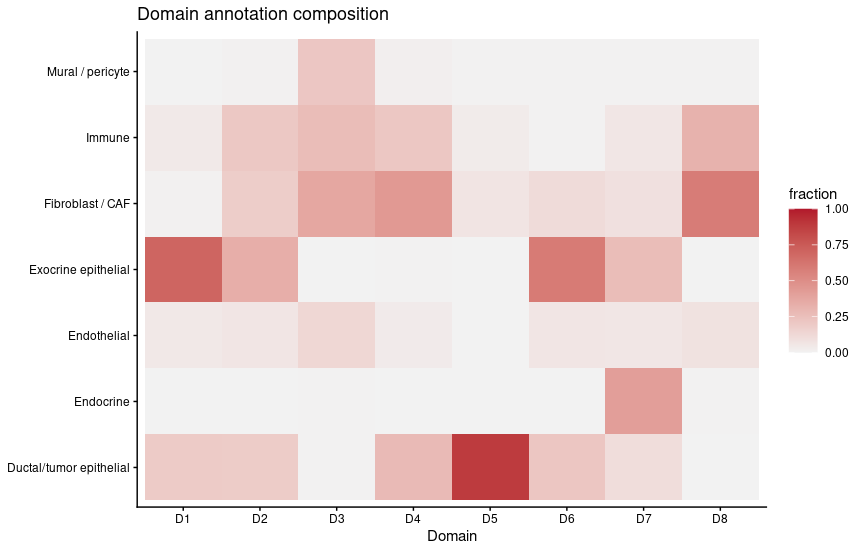

In [ ]:
celladmix_plot_domain_composition(domains)

## Coarse Domain Naming

The suggested labels below are generated from the dominant cell
annotations in each domain. Edit `domain_label_overrides` to assign
manual coarse region classes; the exported `domain_annotation.csv` is
what downstream notebooks should use.

In [ ]:
suggest_domain_labels <- function(composition, top_n = 2) {
  split_comp <- split(composition, composition$domain)
  pieces <- lapply(split_comp, function(df) {
    df <- df[order(-df$fraction), , drop = FALSE]
    top <- head(df[df$fraction > 0, , drop = FALSE], top_n)
    label <- paste(top$annotation, collapse = " + ")
    data.frame(domain = df$domain[[1]], suggested_label = label, stringsAsFactors = FALSE)
  })
  do.call(rbind, pieces)
}

domain_labels <- suggest_domain_labels(domain_composition, top_n = 2)
domain_labels$domain_fine_label <- c(
  D1 = "Exocrine-rich parenchyma",
  D2 = "Mixed exocrine/immune interface",
  D3 = "Vascular stromal niche",
  D4 = "CAF-rich ductal/immune stroma",
  D5 = "Ductal/tumor epithelial domain",
  D6 = "Exocrine-ductal transition",
  D7 = "Endocrine islet-rich domain",
  D8 = "CAF/immune stromal domain"
)[domain_labels$domain]

domain_labels$domain_fine_label[is.na(domain_labels$domain_fine_label)] <-
  paste0(domain_labels$domain[is.na(domain_labels$domain_fine_label)], ": ",
         domain_labels$suggested_label[is.na(domain_labels$domain_fine_label)])

domain_label_overrides <- c(
  D1 = "adjacent_normal",
  D2 = "transition",
  D3 = "transition",
  D4 = "tumor",
  D5 = "tumor",
  D6 = "transition",
  D7 = "adjacent_normal",
  D8 = "tumor"
)
domain_labels$domain_label <- domain_labels$domain_fine_label
if (length(domain_label_overrides)) {
  hit <- match(names(domain_label_overrides), domain_labels$domain)
  domain_labels$domain_label[hit[!is.na(hit)]] <- unname(domain_label_overrides[!is.na(hit)])
}

domain_labels

   domain                               suggested_label
D1     D1 Exocrine epithelial + Ductal/tumor epithelial
D2     D2                  Exocrine epithelial + Immune
D3     D3                     Fibroblast / CAF + Immune
D4     D4    Fibroblast / CAF + Ductal/tumor epithelial
D5     D5    Ductal/tumor epithelial + Fibroblast / CAF
D6     D6 Exocrine epithelial + Ductal/tumor epithelial
D7     D7               Endocrine + Exocrine epithelial
D8     D8                     Fibroblast / CAF + Immune
                 domain_fine_label    domain_label
D1        Exocrine-rich parenchyma adjacent_normal
D2 Mixed exocrine/immune interface      transition
D3          Vascular stromal niche      transition
D4   CAF-rich ductal/immune stroma           tumor
D5  Ductal/tumor epithelial domain           tumor
D6      Exocrine-ductal transition      transition
D7     Endocrine islet-rich domain adjacent_normal
D8       CAF/immune stromal domain           tumor

In [ ]:
domains$domains$domain_label <- domain_labels$domain_label[match(domains$domains$domain, domain_labels$domain)]
domains$domains$domain_fine_label <- domain_labels$domain_fine_label[match(domains$domains$domain, domain_labels$domain)]
write.csv(domains$domains, domains$paths$domain_annotation_path, row.names = FALSE)
cat("Wrote domain annotation:", domains$paths$domain_annotation_path, "\n")

Wrote domain annotation: /home/pkharchenko/cellAdmix/cellAdmix-core/examples/xenium_pancreas_membrane_377_full/project_auto_rank_threads10/annotations/merged_annotation_domains/domain_annotation.csv 

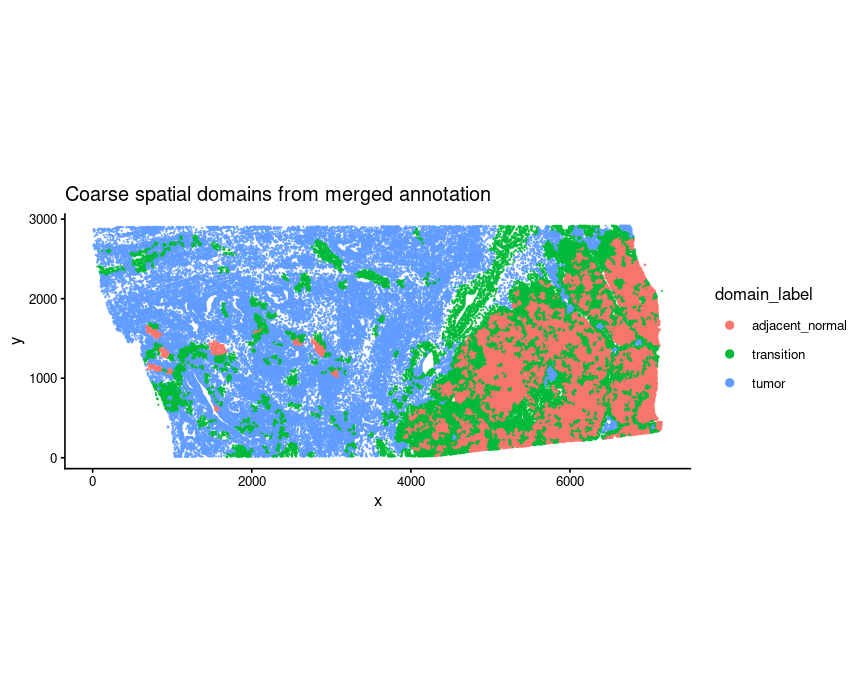

In [ ]:
celladmix_plot_domains_spatial(domains, color = "domain_label", point_size = 0.08, alpha = 0.75) +
  labs(title = "Coarse spatial domains from merged annotation")

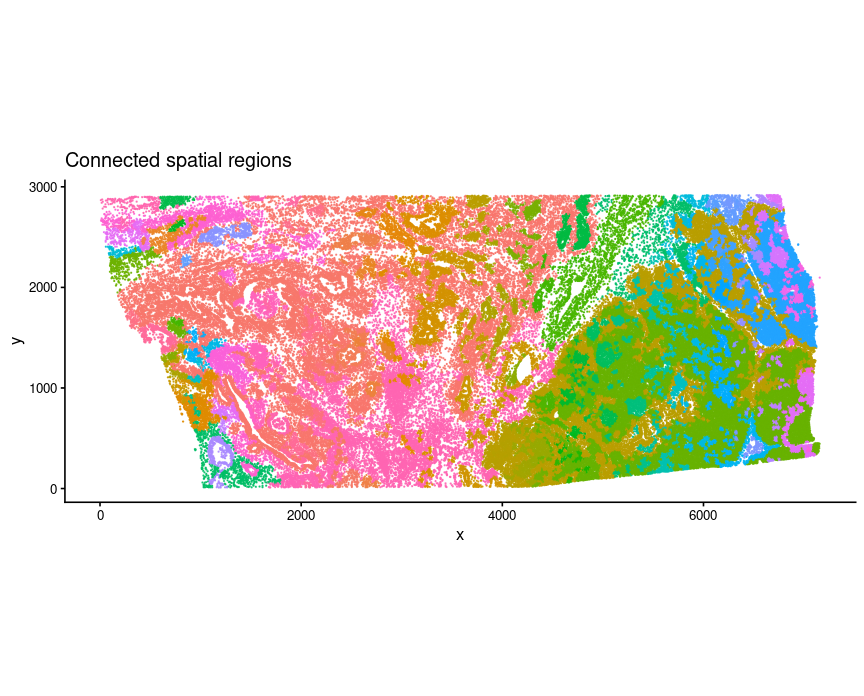

In [ ]:
celladmix_plot_domains_spatial(domains, color = "region_id", point_size = 0.08, alpha = 0.75) +
  guides(color = "none") +
  labs(title = "Connected spatial regions")

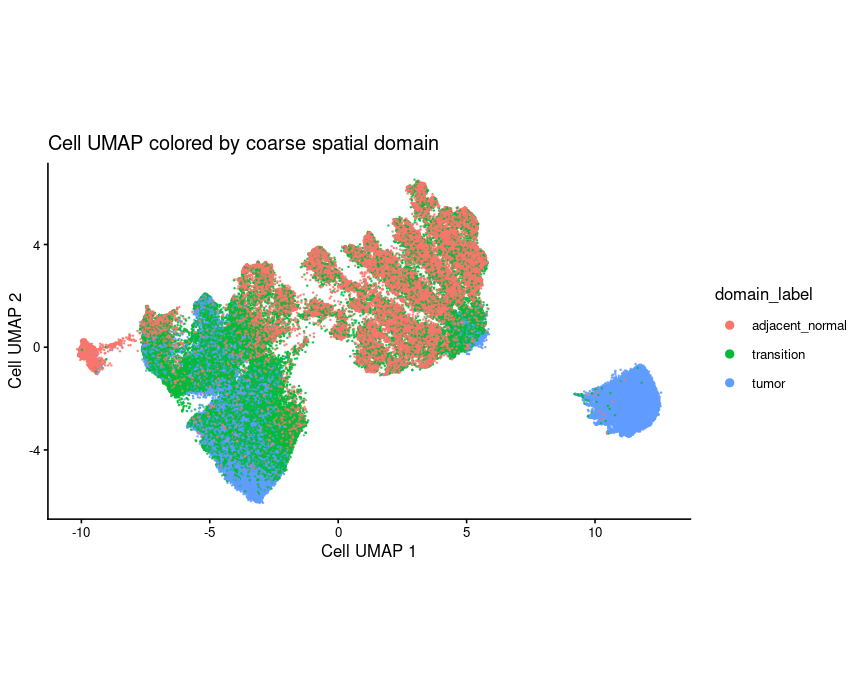

In [ ]:
celladmix_plot_domain_umap(domains, clust = clust, color = "domain_label") +
  labs(title = "Cell UMAP colored by coarse spatial domain")

## Notes on Scaling

For this pancreas panel, the sparse cell-level matrix is small enough to
score directly. On the existing run it is about `541 x 125,723` after
cluster-cell restriction, with about `2.8M` non-zero entries.

The current notebook does not use pseudo-bulk marker testing because
direct cell-level AUC is both simpler and closer to the requested marker
definition. If larger panels make full cell-level scoring too expensive,
the next fallback should be sampled or streaming cell-level detection
AUC before pseudo-bulk: pseudo-bulk comparisons are fast, but require a
more careful count model and do not naturally provide cell-level AUC.